<a href="https://colab.research.google.com/github/Adheeshana/FIVORA/blob/Fabric-classification-experiments/classification_01_after_new_datset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import zipfile
import os

# 1. Google Drive connection
drive.mount('/content/drive')

# 2.dataset path
zip_path = '/content/drive/MyDrive/fabric_classification_dataset.zip'
extract_path = '/content/fabric_dataset_raw'

# extract the Zip file
print("Extracting...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Exracted.....! ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting...
Exracted.....! ✅


In [ ]:
import numpy as np
import cv2
import os
from skimage.feature import local_binary_pattern
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ---------------------------------------------------------
# LBP Parameters for Texture Extraction
# ---------------------------------------------------------
RADIUS = 3
N_POINTS = 8 * RADIUS

def extract_lbp_features(image_array):
    """
    Extracts LBP texture features directly from the image array.
    """
    # FIX: Convert the float64 image array (0.0-1.0) safely back to uint8 (0-255) BEFORE OpenCV processing
    img_uint8 = (image_array * 255).astype(np.uint8)

    # Now OpenCV will process it without the CV_64F error
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, (224, 224))

    lbp = local_binary_pattern(gray, N_POINTS, RADIUS, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, N_POINTS + 3), range=(0, N_POINTS + 2))

    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    return hist

# ---------------------------------------------------------
# Custom Hybrid Data Generator Class
# ---------------------------------------------------------
class AugmentedHybridDataGenerator(Sequence):
    def __init__(self, image_paths, labels, batch_size=32, target_size=(224, 224), num_classes=9, augment=True, **kwargs):
        # FIX: Added super().__init__() to solve the PyDataset UserWarning
        super().__init__(**kwargs)

        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.target_size = target_size
        self.num_classes = num_classes
        self.augment = augment

        self.datagen = ImageDataGenerator(
            rotation_range=40,
            width_shift_range=0.2,
            height_shift_range=0.2,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            fill_mode='nearest'
        )

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / float(self.batch_size)))

    def __getitem__(self, idx):
        batch_paths = self.image_paths[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_labels = self.labels[idx * self.batch_size : (idx + 1) * self.batch_size]

        batch_images = []
        batch_lbp = []
        batch_y = []

        for i in range(len(batch_paths)):
            img = cv2.imread(batch_paths[i])
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, self.target_size)

                if self.augment:
                    img = self.datagen.random_transform(img)

                # Normalize pixel values (This creates the float64 array)
                img_normalized = img / 255.0
                batch_images.append(img_normalized)

                # Send the normalized array to LBP function (which now handles the conversion)
                lbp_features = extract_lbp_features(img_normalized)
                batch_lbp.append(lbp_features)

                batch_y.append(batch_labels[i])

        return {'rgb_image_input': np.array(batch_images), 'lbp_feature_input': np.array(batch_lbp)}, \
               to_categorical(np.array(batch_y), num_classes=self.num_classes)

print("✅ Advanced Augmented Hybrid Data Generator loaded safely! (OpenCV bug fixed)")

✅ Advanced Augmented Hybrid Data Generator loaded safely! (OpenCV bug fixed)


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Concatenate, Dropout
from tensorflow.keras.models import Model

NUM_CLASSES = 9

# 1. CNN Branch (MobileNetV2)
image_input = Input(shape=(224, 224, 3), name='rgb_image_input')
base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)
base_model.trainable = False
cnn_features = GlobalAveragePooling2D()(base_model.output)

# 2. Texture Branch (LBP)
lbp_input = Input(shape=(26,), name='lbp_feature_input')
texture_features = Dense(64, activation='relu')(lbp_input)
texture_features = Dropout(0.3)(texture_features)
texture_features = Dense(32, activation='relu')(texture_features)

# 3. Hybrid Fusion
combined_features = Concatenate()([cnn_features, texture_features])
x = Dense(128, activation='relu')(combined_features)
x = Dropout(0.4)(x)
final_output = Dense(NUM_CLASSES, activation='softmax', name='classification_output')(x)

# Define and Compile
hybrid_model = Model(inputs=[image_input, lbp_input], outputs=final_output)
hybrid_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

print("✅ Hybrid Model is now defined in memory!")

/tmp/ipykernel_8055/1881822379.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)


✅ Hybrid Model is now defined in memory!


In [ ]:
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ---------------------------------------------------------
# 1. Prepare Data Paths and Labels
# ---------------------------------------------------------
base_dir = '/content/fabric_dataset_raw'
original_dataset_dir = os.path.join(base_dir, 'fabric_dataset')

# Handle paths depending on how the zip was extracted
if not os.path.exists(original_dataset_dir):
    original_dataset_dir = base_dir

# Automatically detect class folders
classes = sorted([d for d in os.listdir(original_dataset_dir) if os.path.isdir(os.path.join(original_dataset_dir, d))])
class_indices = {cls: i for i, cls in enumerate(classes)}

print(f"Detected classes for training: {classes}")

all_paths = []
all_labels = []

# Collect all image paths and their corresponding labels
for cls in classes:
    cls_dir = os.path.join(original_dataset_dir, cls)
    for img_name in os.listdir(cls_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_paths.append(os.path.join(cls_dir, img_name))
            all_labels.append(class_indices[cls])

# ---------------------------------------------------------
# 2. Train and Validation Split (80% Train, 20% Validation)
# ---------------------------------------------------------
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

print(f"Training images: {len(train_paths)} (Will be dynamically augmented)")
print(f"Validation images: {len(val_paths)}")

# ---------------------------------------------------------
# 3. Initialize Custom Data Generators
# ---------------------------------------------------------
# Augmentation is TRUE for training to generate new variants on-the-fly
train_gen = AugmentedHybridDataGenerator(
    train_paths, train_labels, batch_size=32, num_classes=9, augment=True
)

# Augmentation is FALSE for validation (we test on original untouched images)
val_gen = AugmentedHybridDataGenerator(
    val_paths, val_labels, batch_size=32, num_classes=9, augment=False
)

# ---------------------------------------------------------
# 4. Define Callbacks and Train the Model
# ---------------------------------------------------------
# Stop training if validation loss doesn't improve for 3 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Save the best model automatically during training
checkpoint = ModelCheckpoint('/content/best_fabric_hybrid_model.keras',
                             monitor='val_accuracy',
                             save_best_only=True)

print("Starting model training... ⏳")

# Train the hybrid model using the custom generators
history = hybrid_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15, # You can increase this later if needed
    callbacks=[early_stop, checkpoint]
)

print("✅ Training completed successfully! Best model saved as 'best_fabric_hybrid_model.keras'")

Detected classes for training: ['Chiffon', 'Cotton', 'Denim', 'Linen', 'Polyester', 'Silk', 'Velvet', 'Viscose', 'Wool']
Training images: 2880 (Will be dynamically augmented)
Validation images: 721
Starting model training... ⏳
Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1275s 14s/step - accuracy: 0.4260 - loss: 1.5669 - val_accuracy: 0.4619 - val_loss: 1.4314
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1274s 14s/step - accuracy: 0.5552 - loss: 1.2414 - val_accuracy: 0.5215 - val_loss: 1.3336
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1245s 14s/step - accuracy: 0.5757 - loss: 1.1912 - val_accuracy: 0.5132 - val_loss: 1.2971
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1224s 14s/step - accuracy: 0.5927 - loss: 1.1146 - val_accuracy: 0.4951 - val_loss: 1.3327
Epoch 5/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1235s 14s/step - accuracy: 0.6097 - loss: 1.0711 - val_accuracy: 0.4993 - val_loss: 1.2909
Epoch 6/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1282s 14s/step - accuracy: 0.6288 - loss: 1.0303 - val_accuracy: 0.5173 - val_loss: 1.2947

📸 Please upload a fabric image from your computer to test...


Saving cottn.jpg to cottn.jpg

⏳ Processing 'cottn.jpg'...
🤖 Model is thinking...
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


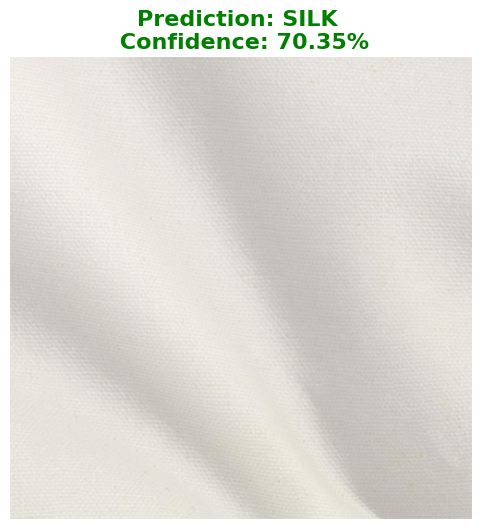

✅ Testing completed!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

print("📸 Please upload a fabric image from your computer to test...")
# This opens the file upload dialog in Colab
uploaded_files = files.upload()

for filename in uploaded_files.keys():
    print(f"\n⏳ Processing '{filename}'...")

    # 1. Read and Process the Image for the CNN Branch
    image_path = '/content/' + filename
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Error: Could not read the image.")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Normalize the image (same as training)
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0) # Reshape to (1, 224, 224, 3)

    # 2. Extract LBP Features for the Texture Branch
    # (Uses the extract_lbp_features function we defined in Step 3)
    lbp_features = extract_lbp_features(img_normalized)
    lbp_input = np.expand_dims(lbp_features, axis=0) # Reshape to (1, 26)

    # 3. Make the Prediction using the Trained Hybrid Model
    print("🤖 Model is thinking...")
    predictions = hybrid_model.predict(
        {'rgb_image_input': img_input, 'lbp_feature_input': lbp_input}
    )

    # 4. Extract Results
    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index] * 100
    # Uses the 'classes' array defined in Step 5
    predicted_class = classes[predicted_index]

    # 5. Display the Image and the Prediction Result
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class.upper()} \n Confidence: {confidence:.2f}%",
              fontsize=16, fontweight='bold', color='green')
    plt.show()

    print("✅ Testing completed!")

📸 Please upload a fabric image from your computer to test...


Saving d.jfif to d.jfif

⏳ Processing 'd.jfif'...
🤖 Model is thinking...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


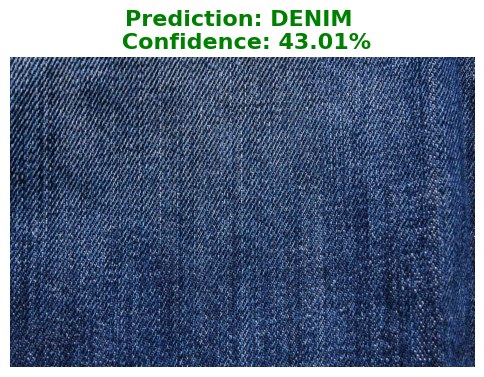

✅ Testing completed!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

print("📸 Please upload a fabric image from your computer to test...")
# This opens the file upload dialog in Colab
uploaded_files = files.upload()

for filename in uploaded_files.keys():
    print(f"\n⏳ Processing '{filename}'...")

    # 1. Read and Process the Image for the CNN Branch
    image_path = '/content/' + filename
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Error: Could not read the image.")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Normalize the image (same as training)
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0) # Reshape to (1, 224, 224, 3)

    # 2. Extract LBP Features for the Texture Branch
    # (Uses the extract_lbp_features function we defined in Step 3)
    lbp_features = extract_lbp_features(img_normalized)
    lbp_input = np.expand_dims(lbp_features, axis=0) # Reshape to (1, 26)

    # 3. Make the Prediction using the Trained Hybrid Model
    print("🤖 Model is thinking...")
    predictions = hybrid_model.predict(
        {'rgb_image_input': img_input, 'lbp_feature_input': lbp_input}
    )

    # 4. Extract Results
    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index] * 100
    # Uses the 'classes' array defined in Step 5
    predicted_class = classes[predicted_index]

    # 5. Display the Image and the Prediction Result
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class.upper()} \n Confidence: {confidence:.2f}%",
              fontsize=16, fontweight='bold', color='green')
    plt.show()

    print("✅ Testing completed!")

📸 Please upload a fabric image from your computer to test...


Saving silk.png to silk.png

⏳ Processing 'silk.png'...
🤖 Model is thinking...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


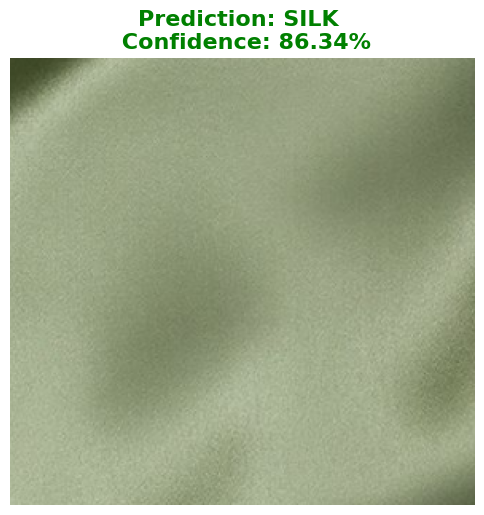

✅ Testing completed!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

print("📸 Please upload a fabric image from your computer to test...")
# This opens the file upload dialog in Colab
uploaded_files = files.upload()

for filename in uploaded_files.keys():
    print(f"\n⏳ Processing '{filename}'...")

    # 1. Read and Process the Image for the CNN Branch
    image_path = '/content/' + filename
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Error: Could not read the image.")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Normalize the image (same as training)
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0) # Reshape to (1, 224, 224, 3)

    # 2. Extract LBP Features for the Texture Branch
    # (Uses the extract_lbp_features function we defined in Step 3)
    lbp_features = extract_lbp_features(img_normalized)
    lbp_input = np.expand_dims(lbp_features, axis=0) # Reshape to (1, 26)

    # 3. Make the Prediction using the Trained Hybrid Model
    print("🤖 Model is thinking...")
    predictions = hybrid_model.predict(
        {'rgb_image_input': img_input, 'lbp_feature_input': lbp_input}
    )

    # 4. Extract Results
    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index] * 100
    # Uses the 'classes' array defined in Step 5
    predicted_class = classes[predicted_index]

    # 5. Display the Image and the Prediction Result
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class.upper()} \n Confidence: {confidence:.2f}%",
              fontsize=16, fontweight='bold', color='green')
    plt.show()

    print("✅ Testing completed!")

📸 Please upload a fabric image from your computer to test...


Saving WhatsApp Image 2026-07-15 at 5.33.11 PM.jpeg to WhatsApp Image 2026-07-15 at 5.33.11 PM.jpeg

⏳ Processing 'WhatsApp Image 2026-07-15 at 5.33.11 PM.jpeg'...
🤖 Model is thinking...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


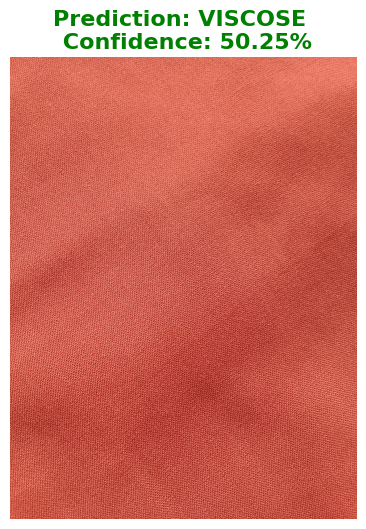

✅ Testing completed!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

print("📸 Please upload a fabric image from your computer to test...")
# This opens the file upload dialog in Colab
uploaded_files = files.upload()

for filename in uploaded_files.keys():
    print(f"\n⏳ Processing '{filename}'...")

    # 1. Read and Process the Image for the CNN Branch
    image_path = '/content/' + filename
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Error: Could not read the image.")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Normalize the image (same as training)
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0) # Reshape to (1, 224, 224, 3)

    # 2. Extract LBP Features for the Texture Branch
    # (Uses the extract_lbp_features function we defined in Step 3)
    lbp_features = extract_lbp_features(img_normalized)
    lbp_input = np.expand_dims(lbp_features, axis=0) # Reshape to (1, 26)

    # 3. Make the Prediction using the Trained Hybrid Model
    print("🤖 Model is thinking...")
    predictions = hybrid_model.predict(
        {'rgb_image_input': img_input, 'lbp_feature_input': lbp_input}
    )

    # 4. Extract Results
    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index] * 100
    # Uses the 'classes' array defined in Step 5
    predicted_class = classes[predicted_index]

    # 5. Display the Image and the Prediction Result
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class.upper()} \n Confidence: {confidence:.2f}%",
              fontsize=16, fontweight='bold', color='green')
    plt.show()

    print("✅ Testing completed!")

📸 Please upload a fabric image from your computer to test...


Saving poly_zoomed.jpg to poly_zoomed.jpg

⏳ Processing 'poly_zoomed.jpg'...
🤖 Model is thinking...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


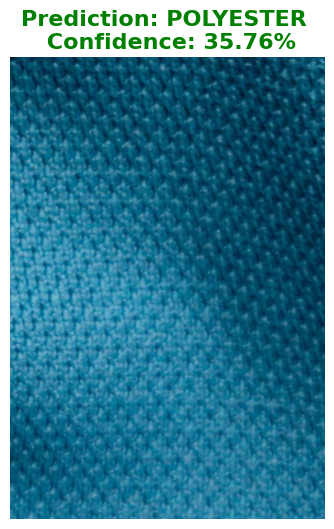

✅ Testing completed!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

print("📸 Please upload a fabric image from your computer to test...")
# This opens the file upload dialog in Colab
uploaded_files = files.upload()

for filename in uploaded_files.keys():
    print(f"\n⏳ Processing '{filename}'...")

    # 1. Read and Process the Image for the CNN Branch
    image_path = '/content/' + filename
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Error: Could not read the image.")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Normalize the image (same as training)
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0) # Reshape to (1, 224, 224, 3)

    # 2. Extract LBP Features for the Texture Branch
    # (Uses the extract_lbp_features function we defined in Step 3)
    lbp_features = extract_lbp_features(img_normalized)
    lbp_input = np.expand_dims(lbp_features, axis=0) # Reshape to (1, 26)

    # 3. Make the Prediction using the Trained Hybrid Model
    print("🤖 Model is thinking...")
    predictions = hybrid_model.predict(
        {'rgb_image_input': img_input, 'lbp_feature_input': lbp_input}
    )

    # 4. Extract Results
    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index] * 100
    # Uses the 'classes' array defined in Step 5
    predicted_class = classes[predicted_index]

    # 5. Display the Image and the Prediction Result
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class.upper()} \n Confidence: {confidence:.2f}%",
              fontsize=16, fontweight='bold', color='green')
    plt.show()

    print("✅ Testing completed!")

📸 Please upload a fabric image from your computer to test...


Saving cot.jpg to cot.jpg

⏳ Processing 'cot.jpg'...
🤖 Model is thinking...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


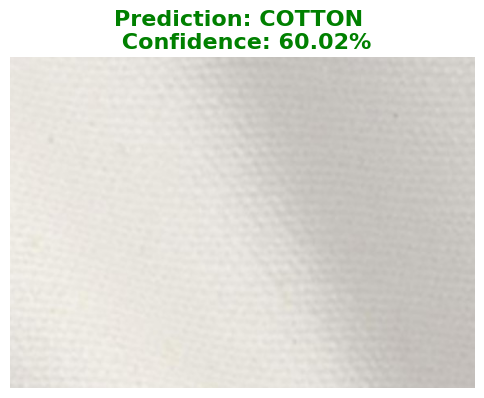

✅ Testing completed!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

print("📸 Please upload a fabric image from your computer to test...")
# This opens the file upload dialog in Colab
uploaded_files = files.upload()

for filename in uploaded_files.keys():
    print(f"\n⏳ Processing '{filename}'...")

    # 1. Read and Process the Image for the CNN Branch
    image_path = '/content/' + filename
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Error: Could not read the image.")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Normalize the image (same as training)
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0) # Reshape to (1, 224, 224, 3)

    # 2. Extract LBP Features for the Texture Branch
    # (Uses the extract_lbp_features function we defined in Step 3)
    lbp_features = extract_lbp_features(img_normalized)
    lbp_input = np.expand_dims(lbp_features, axis=0) # Reshape to (1, 26)

    # 3. Make the Prediction using the Trained Hybrid Model
    print("🤖 Model is thinking...")
    predictions = hybrid_model.predict(
        {'rgb_image_input': img_input, 'lbp_feature_input': lbp_input}
    )

    # 4. Extract Results
    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index] * 100
    # Uses the 'classes' array defined in Step 5
    predicted_class = classes[predicted_index]

    # 5. Display the Image and the Prediction Result
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class.upper()} \n Confidence: {confidence:.2f}%",
              fontsize=16, fontweight='bold', color='green')
    plt.show()

    print("✅ Testing completed!")

📸 Please upload a fabric image from your computer to test...


Saving wool.jpg to wool.jpg

⏳ Processing 'wool.jpg'...
🤖 Model is thinking...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


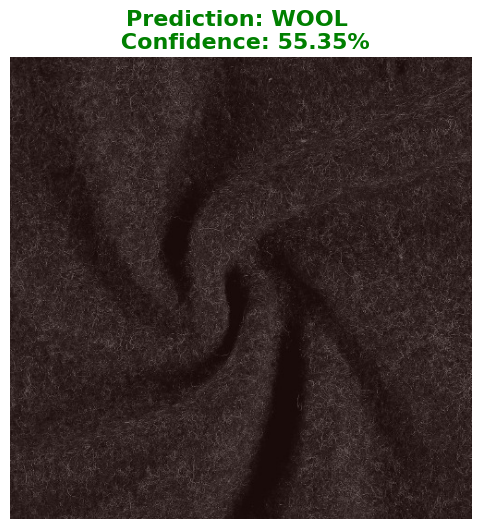

✅ Testing completed!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

print("📸 Please upload a fabric image from your computer to test...")
# This opens the file upload dialog in Colab
uploaded_files = files.upload()

for filename in uploaded_files.keys():
    print(f"\n⏳ Processing '{filename}'...")

    # 1. Read and Process the Image for the CNN Branch
    image_path = '/content/' + filename
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Error: Could not read the image.")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Normalize the image (same as training)
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0) # Reshape to (1, 224, 224, 3)

    # 2. Extract LBP Features for the Texture Branch
    # (Uses the extract_lbp_features function we defined in Step 3)
    lbp_features = extract_lbp_features(img_normalized)
    lbp_input = np.expand_dims(lbp_features, axis=0) # Reshape to (1, 26)

    # 3. Make the Prediction using the Trained Hybrid Model
    print("🤖 Model is thinking...")
    predictions = hybrid_model.predict(
        {'rgb_image_input': img_input, 'lbp_feature_input': lbp_input}
    )

    # 4. Extract Results
    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index] * 100
    # Uses the 'classes' array defined in Step 5
    predicted_class = classes[predicted_index]

    # 5. Display the Image and the Prediction Result
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class.upper()} \n Confidence: {confidence:.2f}%",
              fontsize=16, fontweight='bold', color='green')
    plt.show()

    print("✅ Testing completed!")

📸 Please upload a fabric image from your computer to test...


Saving viscose_captured.jpg to viscose_captured.jpg

⏳ Processing 'viscose_captured.jpg'...
🤖 Model is thinking...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


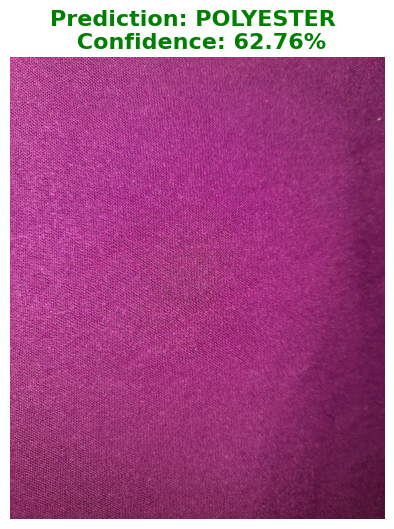

✅ Testing completed!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

print("📸 Please upload a fabric image from your computer to test...")
# This opens the file upload dialog in Colab
uploaded_files = files.upload()

for filename in uploaded_files.keys():
    print(f"\n⏳ Processing '{filename}'...")

    # 1. Read and Process the Image for the CNN Branch
    image_path = '/content/' + filename
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Error: Could not read the image.")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Normalize the image (same as training)
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0) # Reshape to (1, 224, 224, 3)

    # 2. Extract LBP Features for the Texture Branch
    # (Uses the extract_lbp_features function we defined in Step 3)
    lbp_features = extract_lbp_features(img_normalized)
    lbp_input = np.expand_dims(lbp_features, axis=0) # Reshape to (1, 26)

    # 3. Make the Prediction using the Trained Hybrid Model
    print("🤖 Model is thinking...")
    predictions = hybrid_model.predict(
        {'rgb_image_input': img_input, 'lbp_feature_input': lbp_input}
    )

    # 4. Extract Results
    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index] * 100
    # Uses the 'classes' array defined in Step 5
    predicted_class = classes[predicted_index]

    # 5. Display the Image and the Prediction Result
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class.upper()} \n Confidence: {confidence:.2f}%",
              fontsize=16, fontweight='bold', color='green')
    plt.show()

    print("✅ Testing completed!")

📸 Please upload a fabric image from your computer to test...


Saving linen.jpg to linen (2).jpg

⏳ Processing 'linen (2).jpg'...
🤖 Model is thinking...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


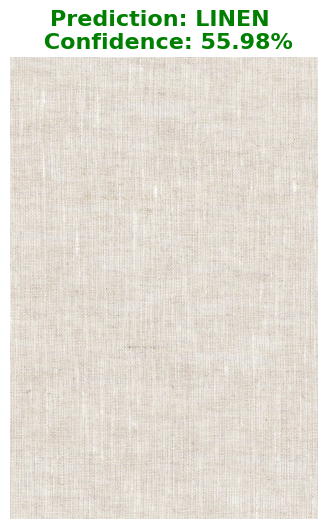

✅ Testing completed!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

print("📸 Please upload a fabric image from your computer to test...")
# This opens the file upload dialog in Colab
uploaded_files = files.upload()

for filename in uploaded_files.keys():
    print(f"\n⏳ Processing '{filename}'...")

    # 1. Read and Process the Image for the CNN Branch
    image_path = '/content/' + filename
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Error: Could not read the image.")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Normalize the image (same as training)
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0) # Reshape to (1, 224, 224, 3)

    # 2. Extract LBP Features for the Texture Branch
    # (Uses the extract_lbp_features function we defined in Step 3)
    lbp_features = extract_lbp_features(img_normalized)
    lbp_input = np.expand_dims(lbp_features, axis=0) # Reshape to (1, 26)

    # 3. Make the Prediction using the Trained Hybrid Model
    print("🤖 Model is thinking...")
    predictions = hybrid_model.predict(
        {'rgb_image_input': img_input, 'lbp_feature_input': lbp_input}
    )

    # 4. Extract Results
    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index] * 100
    # Uses the 'classes' array defined in Step 5
    predicted_class = classes[predicted_index]

    # 5. Display the Image and the Prediction Result
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class.upper()} \n Confidence: {confidence:.2f}%",
              fontsize=16, fontweight='bold', color='green')
    plt.show()

    print("✅ Testing completed!")